# Load Dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../Fitbit/data/fitbit_cleaned.csv")
df.head()

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Fat_Percentage,Water_Intake,...,Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned,Workout_Type_HIIT,Workout_Type_Mixed,Workout_Type_Strength,Workout_Type_Yoga
0,56,0,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,...,1,20.4,9.5,0.847826,8.054348,437.7,1,0,0,0
1,46,1,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,...,0,18.0,3.0,0.546392,1.639175,22.5,0,0,0,1
2,32,0,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,...,1,26.5,9.5,0.853846,8.111538,183.4,1,0,0,0
3,25,1,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,...,0,28.5,3.0,0.550000,1.650000,127.2,0,0,0,1
4,38,1,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,...,0,32.5,7.0,0.654545,4.581818,240.7,0,0,0,0


In [3]:
cluster_df = df.drop(
    columns=[
        "Workout_Type_HIIT",
        "Workout_Type_Mixed",
        "Workout_Type_Strength",
        "Workout_Type_Yoga"
    ]
)
cluster_df.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration', 'Fat_Percentage', 'Water_Intake',
       'Workout_Frequency', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET', 'Calories_Burned'],
      dtype='str')

# Scaling Features

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_df)

# Dimensity Reduction Using PCA

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(cluster_scaled)

# Finding 'K' value using Elbow Method

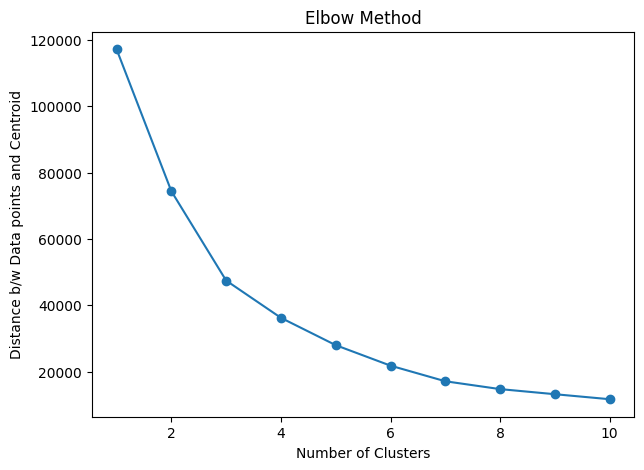

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data_points = []

for k in range(1,11):
    k_means = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    k_means.fit(cluster_pca)
    data_points.append(k_means.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(1,11), data_points, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Distance b/w Data points and Centroid")

plt.show()

# With 3 clusters

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_pca)

cluster_df["Cluster"] = clusters

# Silhouette Score

In [8]:
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_pca, clusters)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.389


# Visualize the clusters

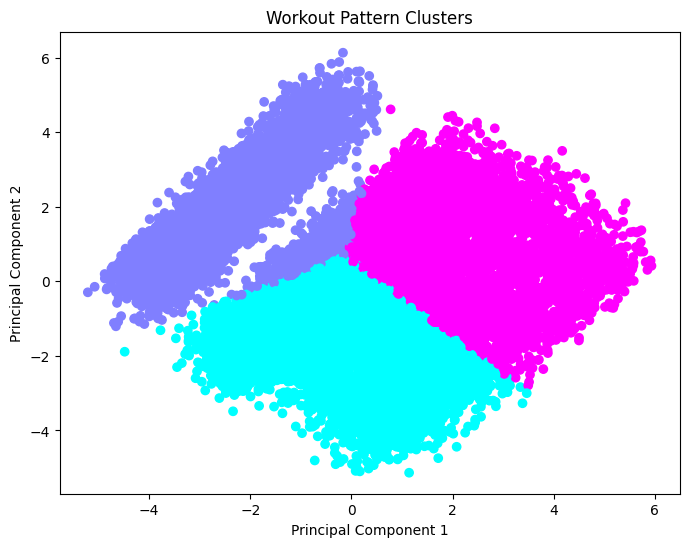

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    cluster_pca[:,0],
    cluster_pca[:,1],
    c=clusters,
    cmap="cool"
)

plt.title("Workout Pattern Clusters")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# Cluster Size Distribution

In [11]:
cluster_sizes = cluster_df["Cluster"].value_counts().sort_index()

print(cluster_sizes)

Cluster
0    6292
1    3314
2    4496
Name: count, dtype: int64


# Cluster Feature Means

In [12]:
cluster_means = cluster_df.groupby("Cluster").mean()

cluster_means

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Fat_Percentage,Water_Intake,Workout_Frequency,Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned
Cluster,,,,,,,,,,,,,,,,,
0,37.559599,0.493325,68.012381,1.679085,182.607915,153.858709,73.463605,0.654574,25.172092,3.289367,3.034488,0.391449,24.049261,7.620153,0.737254,5.703156,252.343810
1,40.717260,0.496379,67.422933,1.678054,178.751660,131.421243,69.077550,0.822850,21.832861,3.790766,4.191310,1.159022,23.880597,3.576343,0.570551,2.098646,114.363820
2,38.270685,0.527802,69.087967,1.683774,181.664146,151.881673,63.740881,1.080819,17.193728,3.888968,5.681495,2.206628,24.309831,7.799155,0.748156,5.918535,432.010665
